# Exploración de Ground Truth — Estaciones de Precipitación en la Sabana de Bogotá

Este notebook identifica y evalúa las estaciones de precipitación disponibles dentro del dominio de estudio (~400×400 km centrado en Bogotá) y determina empíricamente qué años tienen cobertura suficiente para ser usados como ground truth en el modelo de nowcasting.

**Fuentes consultadas:**
- Catálogo Nacional de Estaciones del IDEAM — `hp9r-jxuu` (datos.gov.co)
- Dataset de precipitación sub-horaria IDEAM/IDIGER — `s54a-sgyg` (datos.gov.co)

**Decisiones que documenta este notebook:**
1. Qué estaciones incluir como ground truth
2. Qué años tienen datos suficientes y de calidad
3. Distribución espacial de las estaciones seleccionadas

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import time

## 1. Inventario de estaciones dentro del dominio

Consultamos el catálogo nacional de estaciones del IDEAM (`hp9r-jxuu`) filtrando por el bounding box del dominio de estudio: latitud entre 4.45°N y 5.05°N, longitud entre 74.35°O y 73.85°O. Este bbox corresponde aproximadamente a Bogotá D.C. y los municipios de la Sabana inmediata (Chía, Soacha, Facatativá, Zipaquirá, La Calera, entre otros).

In [4]:
url_catalogo = "https://www.datos.gov.co/resource/hp9r-jxuu.json"
params = {
    "$where": "latitud between 4.45 and 5.05 and longitud between -74.35 and -73.85",
    "$limit": 1000
}

r = requests.get(url_catalogo, params=params)
estaciones = pd.DataFrame(r.json())

# Incluimos todas las estaciones del bbox, activas y suspendidas
# El filtro real de disponibilidad se hace en el paso 2 contra el dataset de precipitación
activas = estaciones.copy()
print(f"Total estaciones en bbox: {len(estaciones)}")
print(f"Estaciones incluidas para evaluación: {len(activas)}")
print(f"\nDistribución por categoría:")
print(activas['categoria'].value_counts())

Total estaciones en bbox: 595
Estaciones incluidas para evaluación: 595

Distribución por categoría:
categoria
Limnimétrica               172
Pluviométrica              141
Climatológica Ordinaria     88
Climatológica Principal     60
Limnigráfica                53
Pluviográfica               35
Meteorológica Especial      31
HidroMeteorologica           6
Agrometeorológica            3
Radio Sonda                  2
Ambiental                    2
Sinóptica Principal          1
Sinóptica Secundaria         1
Name: count, dtype: int64


### 1.1 Filtro por categoría

Para el ground truth de lluvia fuerte necesitamos estaciones que midan precipitación directamente. Las categorías útiles son Pluviométrica, Pluviográfica, Climatológica Principal y Climatológica Ordinaria. Las Limnimétrica y Limnigráfica miden nivel de río, no precipitación.

Las estaciones HidroMeteorologica (6 en el bbox) se incluyen porque son automáticas con telemetría en Bogotá — probablemente miden precipitación además de nivel. Se verifica empíricamente al consultar el dataset de precipitación.

In [5]:
cats_excluir = ['Limnimétrica', 'Limnigráfica', 'Radio Sonda']

candidatas = activas[~activas['categoria'].isin(cats_excluir)].copy()

# Extraer código limpio del nombre (formato: "NOMBRE [CODIGO]")
candidatas['codigo_limpio'] = candidatas['nombre'].str.extract(r'\[(\d+)\]')

print(f"Estaciones candidatas con precipitación: {len(candidatas)}")
print(candidatas[['codigo', 'codigo_limpio', 'nombre', 'categoria', 'tecnologia', 'municipio']].head(10).to_string())

Estaciones candidatas con precipitación: 368
        codigo codigo_limpio                                                        nombre                categoria                 tecnologia    municipio
0   0021205380      21205380                                         HIPOTECHO  [21205380]  Climatológica Ordinaria               Convencional  Bogotá, D.C
1   2120000122    2120000122  COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED) [2120000122]            Pluviométrica  Automática con Telemetría  Bogotá, D.C
2   0021200310      21200310                                     CERRO DE SUBA  [21200310]            Pluviométrica               Convencional  Bogotá, D.C
3   0021206500      21206500                            COLEGIO ABRAHAM LINCOLN [21206500]  Climatológica Ordinaria               Convencional  Bogotá, D.C
4   2120000169    2120000169                         COLEGIO LA BELLEZA (IED) [2120000169]            Pluviométrica  Automática con Telemetría  Bogotá, D.C
5   0021205330     

In [6]:
# Guardar inventario de candidatas
candidatas[['codigo', 'codigo_limpio', 'nombre', 'categoria', 'tecnologia', 'municipio', 'latitud', 'longitud']].to_csv(
    'estaciones_sabana_candidatas.csv', index=False
)
print("Guardado: estaciones_sabana_candidatas.csv")

Guardado: estaciones_sabana_candidatas.csv


## 2. Verificación de disponibilidad de datos de precipitación

El catálogo del IDEAM confirma que las estaciones existen, pero no garantiza que sus datos de precipitación estén disponibles en el dataset `s54a-sgyg` de datos.gov.co. Este dataset contiene registros de precipitación a resolución sub-horaria (~5 minutos) de estaciones automáticas del IDEAM e IDIGER.

**Nota importante:** El portal DHIME del IDEAM solo expone precipitación diaria, mensual y anual — resolución insuficiente para definir eventos de lluvia fuerte horarios. El dataset `s54a-sgyg` es la única fuente pública con resolución sub-horaria identificada.

In [7]:
# Consultar precipitación total anual para cada estación candidata
# Usamos agregación en la API para evitar bajar millones de registros crudos

url_precip = "https://www.datos.gov.co/resource/s54a-sgyg.json"
resultados_anuales = []

for i, cod in enumerate(candidatas['codigo_limpio'].dropna()):
    params = {
        "$select": "codigoestacion, date_trunc_y(fechaobservacion) AS anio, SUM(valorobservado) AS precip_total_mm, COUNT(*) AS n_registros",
        "$where": f"codigoestacion='{cod}'",
        "$group": "codigoestacion, date_trunc_y(fechaobservacion)",
        "$order": "anio ASC",
        "$limit": 100
    }
    r = requests.get(url_precip, params=params)
    data = r.json()
    if isinstance(data, list) and len(data) > 0:
        resultados_anuales.extend(data)
    
    if (i + 1) % 20 == 0:
        print(f"{i+1} estaciones consultadas...")
    
    time.sleep(0.3)

df_anual = pd.DataFrame(resultados_anuales)
df_anual['anio'] = pd.to_datetime(df_anual['anio']).dt.year
df_anual['precip_total_mm'] = pd.to_numeric(df_anual['precip_total_mm'])
df_anual['n_registros'] = pd.to_numeric(df_anual['n_registros'])

df_anual.to_csv('precipitacion_anual_candidatas.csv', index=False)
print(f"\nListo. {len(df_anual)} filas guardadas en precipitacion_anual_candidatas.csv")

20 estaciones consultadas...
40 estaciones consultadas...
60 estaciones consultadas...
80 estaciones consultadas...
100 estaciones consultadas...
120 estaciones consultadas...
140 estaciones consultadas...
160 estaciones consultadas...
180 estaciones consultadas...
200 estaciones consultadas...
220 estaciones consultadas...
240 estaciones consultadas...
260 estaciones consultadas...
280 estaciones consultadas...
300 estaciones consultadas...
320 estaciones consultadas...
340 estaciones consultadas...
360 estaciones consultadas...

Listo. 224 filas guardadas en precipitacion_anual_candidatas.csv


## 3. Selección de años candidatos

Para determinar qué años tienen cobertura suficiente aplicamos un umbral mínimo de registros: a 5 minutos de cadencia, un año completo sin interrupciones tendría ~105,000 registros. Exigimos al menos el 50% (~52,500) para considerar un año como cubierto por una estación.

In [9]:
# Filtrar años con cobertura suficiente (≥50% de registros esperados)
UMBRAL_REGISTROS = 52_500  # 50% de un año completo a 5 min
df_cobertura = df_anual[df_anual['n_registros'] >= UMBRAL_REGISTROS].copy()

# Resumen por año
resumen = df_cobertura.groupby('anio').agg(
    n_estaciones=('codigoestacion', 'count'),
    precip_promedio=('precip_total_mm', 'mean'),
    precip_mediana=('precip_total_mm', 'median')
).reset_index()

print("Resumen de cobertura por año:")
print(resumen.to_string())

Resumen de cobertura por año:
   anio  n_estaciones  precip_promedio  precip_mediana
0  2018            11       117.918182           73.10
1  2019            12       994.310000         1036.76
2  2020            12        99.266667           85.60
3  2024            42       524.376190          502.00
4  2025            44       609.527273          624.80
5  2026            44       336.286364          330.60


### Interpretación y decisión de años

| Año | Estaciones | Decisión | Motivo |
|-----|-----------|----------|--------|
| 2018 | 11 | ❌ Descartado | Red poco densa, precipitación baja |
| 2019 | 12 | ❌ Descartado | Duplicados sistemáticos (~5x registros esperados) |
| 2020 | 12 | ❌ Descartado | Cobertura baja, precipitación anómala |
| 2021 | 0 | ❌ Descartado | Gap en dataset (solo 1 estación con <50% cobertura) |
| 2022 | 0 | ❌ Descartado | Gap en dataset (solo 1 estación con <50% cobertura) |
| 2023 | — | ❌ Descartado | Cobertura insuficiente |
| **2024** | **42** | ✅ Seleccionado | Red densa, datos limpios, un solo satélite (GOES-16) |
| **2025** | **44** | ✅ Seleccionado | Red densa, datos limpios, mayor precipitación |
| 2026 | — | ❌ Descartado | Año incompleto |

**Nota sobre 2019:** Los ~550,000 registros por estación (vs. ~105,000 esperados) indican duplicados sistemáticos en el dataset fuente, que también inflan artificialmente la precipitación total reportada. Este año queda descartado hasta que se limpien los duplicados.

In [10]:
# Verificación del problema de duplicados en 2019
print("Estaciones de 2019 — todas muestran ~550,000 registros (esperado: ~105,000):")
print(df_cobertura[df_cobertura['anio'] == 2019][
    ['codigoestacion', 'precip_total_mm', 'n_registros']
].sort_values('n_registros', ascending=False).to_string())

Estaciones de 2019 — todas muestran ~550,000 registros (esperado: ~105,000):
    codigoestacion  precip_total_mm  n_registros
207     2120000108          1130.00       555311
39      2120000103          1321.70       555131
73      2120000100          1278.30       554034
170     2120000109          1240.30       553492
163     2120000099          1199.80       553072
185     2120000105          1354.40       551996
46      2120000106           841.90       551781
88      2120000107           943.52       550106
24      2120000102           567.30       549137
192     2120700038           650.00       548660
146     2120000104           885.00       542357
9       2120000101           519.50       250607


In [11]:
# Verificación del gap en 2021-2022
gap = df_anual[df_anual['anio'].isin([2021, 2022])][['codigoestacion', 'anio', 'n_registros']]
print(f"Estaciones con datos en 2021-2022: {len(gap)} (de {len(candidatas)} candidatas)")
print(gap)

Estaciones con datos en 2021-2022: 2 (de 368 candidatas)
   codigoestacion  anio  n_registros
96     2120500135  2021        48295
97     2120500135  2022        28648


## 4. Distribución espacial de las estaciones seleccionadas

Verificamos que las 42-43 estaciones seleccionadas cubren el área objetivo (Bogotá D.C. y Sabana) de forma razonablemente distribuida, sin concentraciones que dejen zonas sin cobertura.

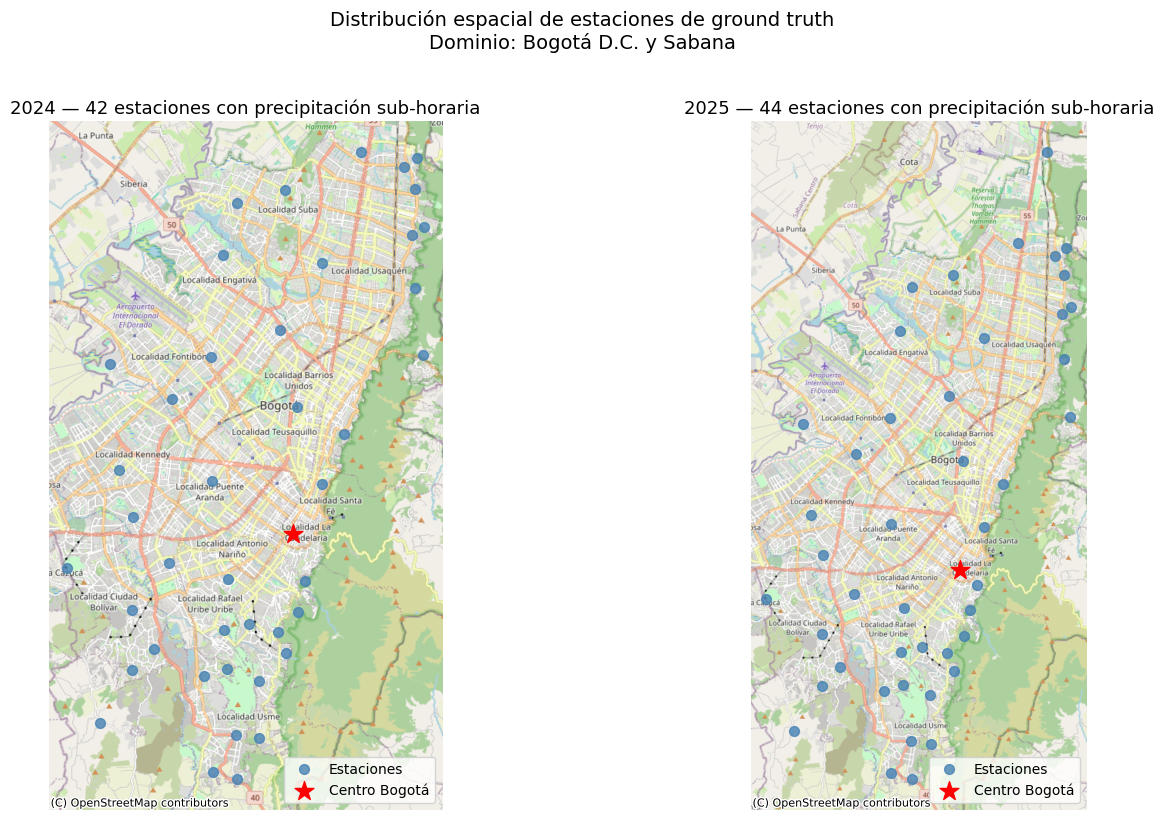

Guardado: mapa_estaciones_ground_truth.png


In [12]:
# Preparar datos de mapa
estaciones_2024 = df_cobertura[df_cobertura['anio'] == 2024]['codigoestacion'].tolist()
estaciones_2025 = df_cobertura[df_cobertura['anio'] == 2025]['codigoestacion'].tolist()

candidatas['codigo_limpio'] = candidatas['codigo_limpio'].astype(str)
mapa_2024 = candidatas[candidatas['codigo_limpio'].isin(estaciones_2024)].copy()
mapa_2025 = candidatas[candidatas['codigo_limpio'].isin(estaciones_2025)].copy()

for df in [mapa_2024, mapa_2025]:
    df['latitud'] = pd.to_numeric(df['latitud'])
    df['longitud'] = pd.to_numeric(df['longitud'])

# Crear GeoDataFrames
def to_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df['longitud'], df['latitud'])],
        crs='EPSG:4326'
    ).to_crs(epsg=3857)

gdf_2024 = to_gdf(mapa_2024)
gdf_2025 = to_gdf(mapa_2025)
centro = gpd.GeoDataFrame(geometry=[Point(-74.077, 4.596)], crs='EPSG:4326').to_crs(epsg=3857)

# Mapa
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, gdf, anio in zip(axes, [gdf_2024, gdf_2025], [2024, 2025]):
    gdf.plot(ax=ax, color='steelblue', markersize=50, alpha=0.8, zorder=3, label='Estaciones')
    centro.plot(ax=ax, color='red', markersize=200, marker='*', zorder=4, label='Centro Bogotá')
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)
    ax.set_title(f'{anio} — {len(gdf)} estaciones con precipitación sub-horaria', fontsize=13)
    ax.set_axis_off()
    ax.legend(loc='lower right')

plt.suptitle('Distribución espacial de estaciones de ground truth\nDominio: Bogotá D.C. y Sabana', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mapa_estaciones_ground_truth.png', dpi=200, bbox_inches='tight')
plt.show()
print("Guardado: mapa_estaciones_ground_truth.png")

## Conclusión

El ground truth del modelo de nowcasting estará compuesto por:
- **42 estaciones** con datos de precipitación sub-horaria (~5 min) para **2024**
- **44 estaciones** con datos de precipitación sub-horaria (~5 min) para **2025**

Todas son estaciones automáticas con telemetría operadas por el IDEAM o el IDIGER, distribuidas sobre Bogotá D.C. y municipios aledaños de la Sabana. Los datos se obtienen del dataset `s54a-sgyg` de datos.gov.co.

El siguiente paso es definir el umbral de **lluvia fuerte** (mm/h) y etiquetar los eventos hora a hora para cada estación en los años seleccionados.